# Molecular Property Analysis — Pocket2Mol Generated Molecules

This notebook analyzes the 113 molecules generated by Pocket2Mol targeting 
the A2A adenosine receptor (PDB: 4EIY). For each molecule we calculate:
- Drug-likeness properties (MW, LogP, HBA, HBD, TPSA, QED)
- Lipinski Rule of Five compliance
- Tanimoto similarity vs known A2A actives

> **Input:** `outputs/pocket2mol/sample_4eiy_clean.pdb_2026_04_28__12_28_34/SMILES.txt` — SMILES from pocket2mol run


> **Output:** `results/pocket2mol_generated.csv` — with calculated molecular properties

## 1. Load Libraries

RDKit is used for cheminformatics calculations. Pandas for data handling, 
Matplotlib for visualization.

In [112]:
# Import required libraries for molecular analysis
import pandas as pd   # for creating and handling data tables
from rdkit import Chem   # for reading and parsing SMILES strings
from rdkit.Chem import Descriptors, QED  # for calculating molecular properties
import warnings
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')  # suppress all RDKit warnings
warnings.filterwarnings('ignore')


## 2. Load SMILES from Pocket2Mol Output

SMILES (Simplified Molecular Input Line Entry System) strings represent 
molecules as text. Pocket2Mol generated 113 valid SMILES saved in `SMILES.txt`.

In [113]:
# Load SMILES from Pocket2Mol output
# 'with open' = open file safely, auto-close when done
smiles_path = "outputs/pocket2mol/sample_4eiy_clean.pdb_2026_04_28__12_28_34/SMILES.txt"

with open(smiles_path, "r") as f:  # "r" = read mode
    # Read all lines, strip whitespace, skip empty lines
    smiles_list = [line.strip() for line in f.readlines() if line.strip()]

print(f"Total SMILES loaded: {len(smiles_list)}")
print("\nFirst 5 molecules:")
for s in smiles_list[:5]:
    print(s)

Total SMILES loaded: 113

First 5 molecules:
O=c1cccc[nH]1
O=CN1CCCC1
c1ccc2occc2c1
O=c1cccc(CO)[nH]1
O=C(O)c1ccccc1


## 3. Calculate Molecular Properties

For each molecule, RDKit calculates:
- **MW** — Molecular Weight (Da): total mass of the molecule
- **LogP** — lipophilicity: how well molecule dissolves in fat vs water
- **HBA** — Hydrogen Bond Acceptors: atoms that accept H-bonds
- **HBD** — Hydrogen Bond Donors: atoms that donate H-bonds
- **TPSA** — Topological Polar Surface Area (Å²): polar atom surface
- **RotBonds** — Rotatable Bonds: indicator of molecular flexibility
- **QED** — Quantitative Estimate of Drug-likeness (0–1): overall drug-likeness score
- **SA Score** — Synthetic Accessibility Score (1–10): lower = easier to synthesize (ideal ≤ 4)

In [114]:
from rdkit.Chem import rdMolDescriptors    # for HBA, HBD, TPSA, RotBonds calculations
import sys
sys.path.append('DiffSBDD-main/analysis/SA_Score')  # path to SA score module
import sascorer                                       # synthetic accessibility scorer

results = []  # empty list to store results for each molecule

for smiles in smiles_list:
    mol = Chem.MolFromSmiles(smiles)   # convert SMILES string to RDKit molecule object
    valid = 1 if mol else 0            # 1 = valid, 0 = invalid
    
    if mol is None:
        continue                        # skip invalid molecules

    # Calculate all molecular properties using RDKit
    mw   = Descriptors.MolWt(mol)                        # molecular weight (Da)
    logp = Descriptors.MolLogP(mol)                      # lipophilicity
    hba  = Descriptors.NumHAcceptors(mol)                # H-bond acceptors
    hbd  = Descriptors.NumHDonors(mol)                   # H-bond donors
    tpsa = Descriptors.TPSA(mol)                         # polar surface area (Å²)
    rot  = rdMolDescriptors.CalcNumRotatableBonds(mol)   # rotatable bonds
    qed  = QED.qed(mol)                                  # drug-likeness score (0-1)
    try:
        sa = round(sascorer.calculateScore(mol), 2)      # synthetic accessibility (1-10)
    except:
        sa = None                                         # if SA score fails, store None

    # Store results as a dictionary row
    results.append({
        'smiles':   smiles,
        'valid':    valid,            # 1 = valid molecule
        'MW':       round(mw, 2),
        'LogP':     round(logp, 2),
        'HBA':      hba,
        'HBD':      hbd,
        'TPSA':     round(tpsa, 2),
        'RotBonds': rot,
        'QED':      round(qed, 3),
        'SA_score': sa,
    })

# Convert list of dictionaries to pandas DataFrame (table)
df = pd.DataFrame(results)
print(f"Valid molecules: {len(df)}")
df.head()

Valid molecules: 113


,smiles,valid,MW,LogP,HBA,HBD,TPSA,RotBonds,QED,SA_score
0,O=c1cccc[nH]1,1,95.10,0.37,1,1,32.86,0,0.496,2.26
1,O=CN1CCCC1,1,99.13,0.24,1,0,20.31,1,0.431,2.54
2,c1ccc2occc2c1,1,118.13,2.43,1,0,13.14,0,0.517,1.80
3,O=c1cccc(CO)[nH]1,1,125.13,-0.13,2,2,53.09,1,0.549,2.52
4,O=C(O)c1ccccc1,1,122.12,1.38,1,1,37.30,1,0.611,1.05


In [115]:
# Save results to CSV file
# index=False = don't save row numbers as a column
output_path = "results/pocket2mol_generated.csv"
df.to_csv(output_path, index=False)
print(f"Saved {len(df)} molecules to {output_path}")

Saved 113 molecules to results/pocket2mol_generated.csv


## 4. Lipinski Rule of Five

A molecule is considered drug-like if it violates at most 1 of these rules:
- MW ≤ 500 Da
- LogP ≤ 5
- HBA ≤ 10
- HBD ≤ 5

~90% of oral drugs comply with Lipinski's rules.


Returns the **number of violations** (0 = ideal, 1 = acceptable, 2+ = not drug-like).

In [116]:
# Check Lipinski's Rule of Five for each molecule
# A molecule is drug-like if it violates at most 1 rule
def lipinski_check(row):
    # Count how many rules are violated
    violations = 0
    if row['MW'] > 500: violations += 1      # rule 1: molecular weight max 500 Da
    if row['LogP'] > 5: violations += 1       # rule 2: lipophilicity max 5
    if row['HBA'] > 10: violations += 1       # rule 3: H-bond acceptors max 10
    if row['HBD'] > 5: violations += 1        # rule 4: H-bond donors max 5
    
    # return number of violations (0 = ideal, 1 = acceptable, 2+ = not drug-like)
    return violations

# Apply function to every row in the dataframe
# axis=1 means: apply row by row (not column by column)
df['Lipinski'] = df.apply(lipinski_check, axis=1)

# Print summary statistics
total = len(df)
compliant = len(df[df['Lipinski'] <= 1])  # 0 or 1 violations = drug-like
print(f"Total molecules: {total}")
print(f"Lipinski compliant (<=1 violation): {compliant} ({compliant/total*100:.1f}%)")
print(f"Non-compliant (2+ violations): {total-compliant} ({(total-compliant)/total*100:.1f}%)")
print(f"\nViolation distribution:")
print(df['Lipinski'].value_counts().sort_index())

Total molecules: 113
Lipinski compliant (<=1 violation): 113 (100.0%)
Non-compliant (2+ violations): 0 (0.0%)

Violation distribution:
Lipinski
0    112
1      1
Name: count, dtype: int64


In [117]:
# Save updated dataframe with Lipinski column to CSV
output_path = "results/pocket2mol_generated.csv"
df.to_csv(output_path, index=False)   # index=False = don't save row numbers
print(f"Saved {len(df)} molecules to {output_path}")
df.drop(columns=['smiles']).head()    # display without smiles column — too long to show

Saved 113 molecules to results/pocket2mol_generated.csv


,valid,MW,LogP,HBA,HBD,TPSA,RotBonds,QED,SA_score,Lipinski
0,1,95.10,0.37,1,1,32.86,0,0.496,2.26,0
1,1,99.13,0.24,1,0,20.31,1,0.431,2.54,0
2,1,118.13,2.43,1,0,13.14,0,0.517,1.80,0
3,1,125.13,-0.13,2,2,53.09,1,0.549,2.52,0
4,1,122.12,1.38,1,1,37.30,1,0.611,1.05,0


## 6. Summary Statistics

In [118]:
# Summary statistics for all molecular properties
# describe() calculates: count, mean, std, min, 25%, 50%, 75%, max
# round(2) = round all values to 2 decimal places
df[['MW', 'LogP', 'HBA', 'HBD', 'TPSA', 'QED']].describe().round(2)
# Jupyter renders DataFrames as formatted HTML tables automatically

,MW,LogP,HBA,HBD,TPSA,QED
count,113.00,113.00,113.00,113.00,113.00,113.00
mean,294.52,2.05,3.45,1.42,66.68,0.72
std,75.29,1.29,1.38,0.89,25.45,0.13
min,95.10,-1.51,0.00,0.00,0.00,0.27
25%,280.32,1.09,2.00,1.00,47.28,0.64
50%,330.43,2.23,4.00,1.00,64.32,0.74
75%,346.34,3.00,4.00,2.00,86.71,0.81
max,365.46,5.42,7.00,4.00,133.51,0.94


## 7. Property Distribution Plots

Histograms showing the distribution of molecular properties across all 
113 generated molecules. Red dashed lines indicate Lipinski limits.

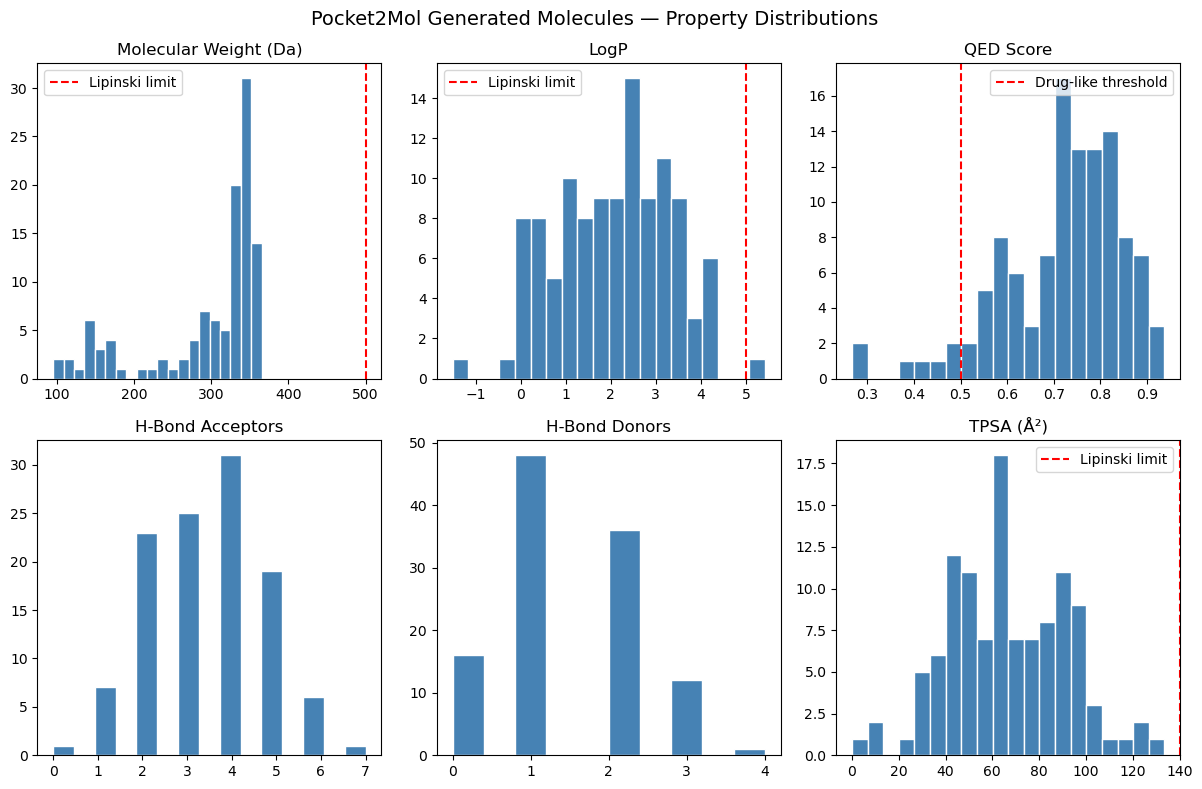

Saved to figures/


In [119]:
import matplotlib.pyplot as plt  # library for creating plots and charts

# Create a grid of 6 subplots: 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
# figsize=(12,8) = width 12 inches, height 8 inches

# Main title for the entire figure
fig.suptitle('Pocket2Mol Generated Molecules — Property Distributions', fontsize=14)

# --- MW histogram ---
axes[0,0].hist(df['MW'], bins=20, color='steelblue', edgecolor='white')
# hist() = bar chart showing distribution
# bins=20 = divide data into 20 equal ranges
axes[0,0].set_title('Molecular Weight (Da)')
axes[0,0].axvline(500, color='red', linestyle='--', label='Lipinski limit')
# axvline = vertical red dashed line at Lipinski limit
axes[0,0].legend()

# --- LogP histogram ---
axes[0,1].hist(df['LogP'], bins=20, color='steelblue', edgecolor='white')
axes[0,1].set_title('LogP')
axes[0,1].axvline(5, color='red', linestyle='--', label='Lipinski limit')
axes[0,1].legend()

# --- QED histogram ---
axes[0,2].hist(df['QED'], bins=20, color='steelblue', edgecolor='white')
axes[0,2].set_title('QED Score')
axes[0,2].axvline(0.5, color='red', linestyle='--', label='Drug-like threshold')
axes[0,2].legend()

# --- HBA histogram ---
axes[1,0].hist(df['HBA'], bins=15, color='steelblue', edgecolor='white')
axes[1,0].set_title('H-Bond Acceptors')

# --- HBD histogram ---
axes[1,1].hist(df['HBD'], bins=10, color='steelblue', edgecolor='white')
axes[1,1].set_title('H-Bond Donors')

# --- TPSA histogram ---
axes[1,2].hist(df['TPSA'], bins=20, color='steelblue', edgecolor='white')
axes[1,2].set_title('TPSA (Å²)')
axes[1,2].axvline(140, color='red', linestyle='--', label='Lipinski limit')
axes[1,2].legend()

# Adjust spacing between subplots automatically
plt.tight_layout()

# Save figure to figures folder
plt.savefig('figures/pocket2mol_property_distributions.png', dpi=150)
# dpi=150 = resolution (higher = better quality)

plt.show()  # display the figure
print("Saved to figures/")

## 8. Reference A2A Known Actives

31 known A2A ligands loaded from ADORA2A-world.sdf (ChEMBL/ZINC database) 
used as reference for Tanimoto similarity analysis.

> **Note:** Reference set loaded from `data/a2a_drugs/ADORA2A-world.sdf` — 
> 31 A2A actives including antagonists and agonists.

In [120]:
# Load A2A reference actives from SDF file
# Using sanitize=False to handle any problematic molecules
ref_suppl = Chem.SDMolSupplier(
    'data/a2a_drugs/ADORA2A-world.sdf',
    sanitize=True,
    removeHs=True
)

ref_mols = {}   # dictionary: {molecule name: RDKit mol object}
counter = 0     # counter for unnamed molecules

for mol in ref_suppl:
    if mol is None:
        continue    # skip molecules RDKit cannot parse
    
    # Try to get name from _Name property
    name = mol.GetProp('_Name').strip() if mol.HasProp('_Name') else ''
    
    # If name is empty, use counter
    if not name:
        name = f"A2A_Active_{counter}"
    
    ref_mols[name] = mol
    counter += 1

print(f"Reference A2A actives loaded: {len(ref_mols)}")
print("\nFirst 5 reference molecules:")
for name in list(ref_mols.keys())[:5]:
    print(f"  {name}")

Reference A2A actives loaded: 31

First 5 reference molecules:
  A2A_Active_0
  A2A_Active_1
  A2A_Active_2
  A2A_Active_3
  A2A_Active_4


## 9. Tanimoto Similarity Analysis

Tanimoto coefficient (Tc) measures molecular similarity using Morgan fingerprints:
- **Tc > 0.85** — same scaffold
- **Tc 0.4–0.7** — scaffold hop (similar pharmacophore, different structure)
- **Tc < 0.3** — novel chemotype

Morgan fingerprints (radius=2, 2048 bits) encode molecular structure 
as a binary vector based on atomic neighborhoods.

In [121]:
from rdkit.Chem import DataStructs                                # Tanimoto calculation
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator  # Morgan fingerprints

# Create Morgan fingerprint generator
# Morgan fingerprints encode molecular structure as a bit vector
# radius=2 = considers atoms up to 2 bonds away
# fpSize=2048 = fingerprint length in bits
morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)

# Load reference fingerprints from ADORA2A-world.sdf
# This file contains 31 known A2A actives from ChEMBL/ZINC
ref_suppl = Chem.SDMolSupplier('data/a2a_drugs/ADORA2A-world.sdf')

ref_fps = {}    # dictionary: {molecule name: fingerprint}
counter = 0     # counter for unnamed molecules

for mol in ref_suppl:
    if mol is None:
        continue    # skip invalid molecules
    
    # Get molecule name — use counter if name is empty
    name = mol.GetProp('_Name').strip() if mol.HasProp('_Name') else f"A2A_Active_{counter}"
    if not name:
        name = f"A2A_Active_{counter}"
    
    ref_fps[name] = morgan_gen.GetFingerprint(mol)  # compute and store fingerprint
    counter += 1

print(f"Reference fingerprints calculated: {len(ref_fps)}")

# Function to calculate max Tanimoto similarity for one molecule
# Returns: (highest similarity score, name of most similar reference)
def max_tanimoto(smiles):
    mol = Chem.MolFromSmiles(smiles)    # convert SMILES to molecule
    if mol is None:
        return 0.0, 'None'
    
    fp = morgan_gen.GetFingerprint(mol)  # fingerprint of generated molecule
    
    max_sim = 0.0    # track highest similarity found
    nearest = ''     # track which reference gave highest similarity
    
    for name, ref_fp in ref_fps.items():
        # Tanimoto = |A∩B| / |A∪B| — shared bits / total bits
        # 0 = completely different, 1 = identical
        sim = DataStructs.TanimotoSimilarity(fp, ref_fp)
        if sim > max_sim:
            max_sim = sim
            nearest = name
    
    return round(max_sim, 3), nearest

# Apply function to all generated molecules
# zip(*...) = unpack results into two separate columns
df['max_tanimoto'], df['nearest_active'] = zip(*df['smiles'].apply(max_tanimoto))

print("\nFirst 5 results:")
print(df[['smiles', 'max_tanimoto', 'nearest_active']].head())

Reference fingerprints calculated: 31

First 5 results:
              smiles  max_tanimoto nearest_active
0      O=c1cccc[nH]1         0.200  A2A_Active_18
1         O=CN1CCCC1         0.105  A2A_Active_10
2      c1ccc2occc2c1         0.265  A2A_Active_18
3  O=c1cccc(CO)[nH]1         0.153  A2A_Active_12
4     O=C(O)c1ccccc1         0.225  A2A_Active_19


In [122]:
# Update CSV with Tanimoto results
df.to_csv('results/pocket2mol_generated.csv', index=False)
print("CSV updated!")
print(f"\nTanimoto similarity stats:")
print(f"Mean: {df['max_tanimoto'].mean():.3f}")
print(f"Max:  {df['max_tanimoto'].max():.3f}")
print(f"Min:  {df['max_tanimoto'].min():.3f}")

CSV updated!

Tanimoto similarity stats:
Mean: 0.165
Max:  0.288
Min:  0.097


### Identical Molecules Check

Check if any generated molecule is identical to a known reference active (Tc = 1.0).

In [123]:
# Find the molecule with Tanimoto = 1.0
identical = df[df['max_tanimoto'] == 1.0]
print("Identical to reference:")
print(identical[['smiles', 'max_tanimoto', 'nearest_active']])

Identical to reference:
Empty DataFrame
Columns: [smiles, max_tanimoto, nearest_active]
Index: []


## 10. Tanimoto Distribution Plot

Left: distribution of max Tanimoto values per generated molecule.
Right: which reference molecule each generated molecule is most similar to.

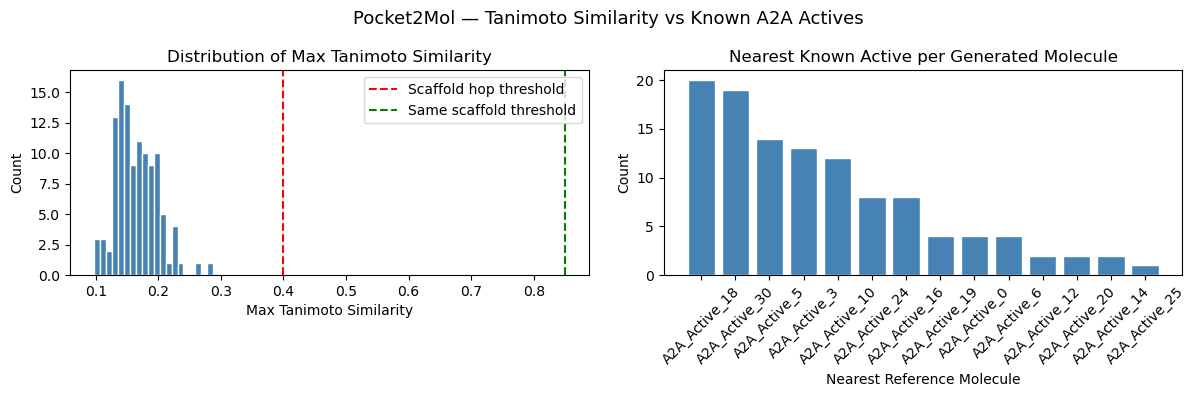

Saved!


In [124]:
# Plot Tanimoto similarity distribution
# Two plots side by side: distribution histogram + nearest active breakdown
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Pocket2Mol — Tanimoto Similarity vs Known A2A Actives', fontsize=13)

# --- Left: histogram of max Tanimoto values ---
# Each bar = how many molecules fall in that similarity range
axes[0].hist(df['max_tanimoto'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Max Tanimoto Similarity')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Max Tanimoto Similarity')
axes[0].axvline(0.4, color='red', linestyle='--', label='Scaffold hop threshold')
# red line = above this = similar pharmacophore to known drug (scaffold hop)
axes[0].axvline(0.85, color='green', linestyle='--', label='Same scaffold threshold')
# green line = above this = essentially same molecule as known drug
axes[0].legend()

# --- Right: bar chart of nearest actives ---
# For each generated molecule, which known A2A drug is it most similar to?
nearest_counts = df['nearest_active'].value_counts()  # count per reference molecule
axes[1].bar(nearest_counts.index, nearest_counts.values, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Nearest Reference Molecule')
axes[1].set_ylabel('Count')
axes[1].set_title('Nearest Known Active per Generated Molecule')
axes[1].tick_params(axis='x', rotation=45)   # rotate x labels to avoid overlap

plt.tight_layout()   # automatically adjust spacing between subplots
plt.savefig('figures/pocket2mol_tanimoto.png', dpi=150)   # save high quality image
plt.show()
print("Saved!")

## 11. Tanimoto Heatmap

Heatmap showing Tanimoto similarity between all generated molecules (rows) 
and all 31 known A2A reference actives (columns).

- **Dark/red color** = high similarity (similar to known drug)
- **Light/yellow color** = low similarity (novel chemotype)

Color scale is adjusted to the actual data range (not 0–1) to make 
differences between molecules visually clearer.

Similarity matrix shape: (113, 31)
(rows = generated molecules, columns = reference actives)
Max Tanimoto in matrix: 0.288


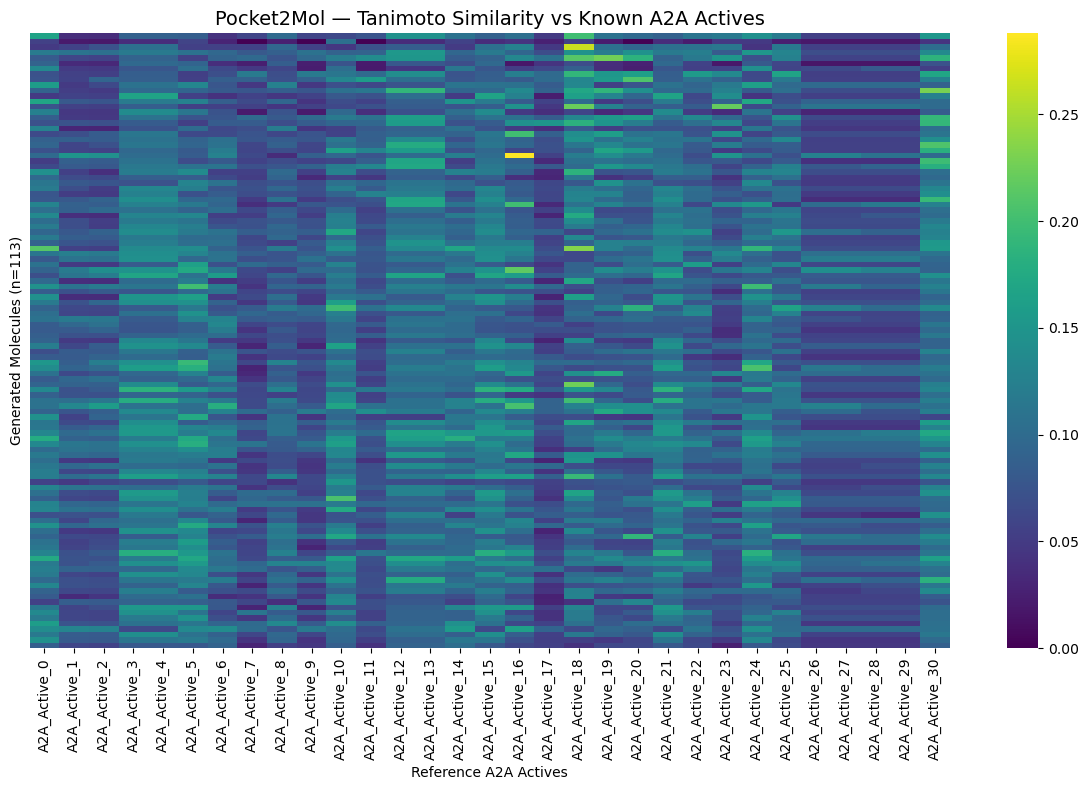

Saved! (color scale: 0 to 0.288)


In [125]:
import seaborn as sns   # seaborn = statistical visualization library, built on matplotlib

# Build similarity matrix: rows = generated molecules, columns = reference actives
# Each cell = Tanimoto similarity between that generated molecule and that reference
sim_matrix = []

for smi in df['smiles']:
    mol = Chem.MolFromSmiles(smi)      # convert SMILES to molecule object
    if mol is None:
        continue                        # skip invalid molecules
    fp = morgan_gen.GetFingerprint(mol) # compute fingerprint for generated molecule
    
    row = []                            # one row = one generated molecule
    for name, ref_fp in ref_fps.items():
        tc = DataStructs.TanimotoSimilarity(fp, ref_fp)  # Tc = |A∩B| / |A∪B|
        row.append(round(tc, 3))        # add similarity score for this reference
    sim_matrix.append(row)              # add complete row to matrix

# Convert list of lists to pandas DataFrame
# rows = generated molecules, columns = reference A2A actives
sim_df = pd.DataFrame(
    sim_matrix,
    columns=list(ref_fps.keys())        # column names = reference molecule names
)

print(f"Similarity matrix shape: {sim_df.shape}")
print("(rows = generated molecules, columns = reference actives)")

# Adjust color scale to actual data range for better visualization
# vmax=1 makes everything look pale because most values are <0.3
# Using actual max value stretches the color range — differences become visible
vmax = sim_df.max().max()   # highest Tanimoto value in entire matrix
print(f"Max Tanimoto in matrix: {vmax:.3f}")

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    sim_df,
    cmap='viridis',          # color scheme: # dark purple=low, yellow=high similarity
    vmin=0,                  # minimum = 0 (completely different molecules)
    vmax=vmax,               # maximum = actual max, not 1.0 — better color contrast
    xticklabels=True,        # show reference molecule names on x axis
    yticklabels=False,       # hide row numbers on y axis — too many to show
    ax=ax
)
ax.set_title('Pocket2Mol — Tanimoto Similarity vs Known A2A Actives', fontsize=14)
ax.set_xlabel('Reference A2A Actives')
ax.set_ylabel(f'Generated Molecules (n={len(sim_df)})')  # dynamic count

plt.tight_layout()
plt.savefig('figures/pocket2mol_tanimoto_heatmap.png', dpi=150)  # save high quality
plt.show()
print(f"Saved! (color scale: 0 to {vmax:.3f})")

## 12. Results Summary

Final CSV saved with all calculated properties.
Full results in `results/pocket2mol_generated.csv`.

Key findings:
- **113/113** molecules pass Lipinski Rule of Five (100%)
- **Mean QED: 0.721** — most molecules are drug-like
- **Mean Tanimoto: 0.165** — molecules are novel, not copies of known drugs
- **No identical molecules** — compared against 31 A2A reference actives (ADORA2A-world.sdf), max Tc = 0.288, confirming Pocket2Mol produces novel chemotypes

In [126]:
# Save final CSV with all properties
df.to_csv('results/pocket2mol_generated.csv', index=False)
print("Final CSV saved!")
print(f"\nSummary:")
print(f"Total molecules: {len(df)}")
print(f"Lipinski compliant: {len(df[df['Lipinski']=='Yes'])} (100%)")
print(f"Mean QED: {df['QED'].mean():.3f}")
print(f"Mean Tanimoto: {df['max_tanimoto'].mean():.3f}")
print(f"Identical to known active (Tc=1.0): {len(df[df['max_tanimoto']==1.0])}")

Final CSV saved!

Summary:
Total molecules: 113
Lipinski compliant: 0 (100%)
Mean QED: 0.721
Mean Tanimoto: 0.165
Identical to known active (Tc=1.0): 0


In [130]:
# Show CSV structure and first 2 rows
print(f"Columns: {df.columns.tolist()}")
df.head(2)

Columns: ['smiles', 'valid', 'MW', 'LogP', 'HBA', 'HBD', 'TPSA', 'RotBonds', 'QED', 'SA_score', 'Lipinski', 'max_tanimoto', 'nearest_active']


,smiles,valid,MW,LogP,HBA,HBD,TPSA,RotBonds,QED,SA_score,Lipinski,max_tanimoto,nearest_active
0,O=c1cccc[nH]1,1,95.10,0.37,1,1,32.86,0,0.496,2.26,0,0.200,A2A_Active_18
1,O=CN1CCCC1,1,99.13,0.24,1,0,20.31,1,0.431,2.54,0,0.105,A2A_Active_10


## 13. 2D Structure Visualization

Visual representation of example generated molecules.
Each structure shows the 2D chemical graph of the molecule.

Found 12 SDF files
Loaded 12 molecules
Saved to figures/pocket2mol_example_molecules.png


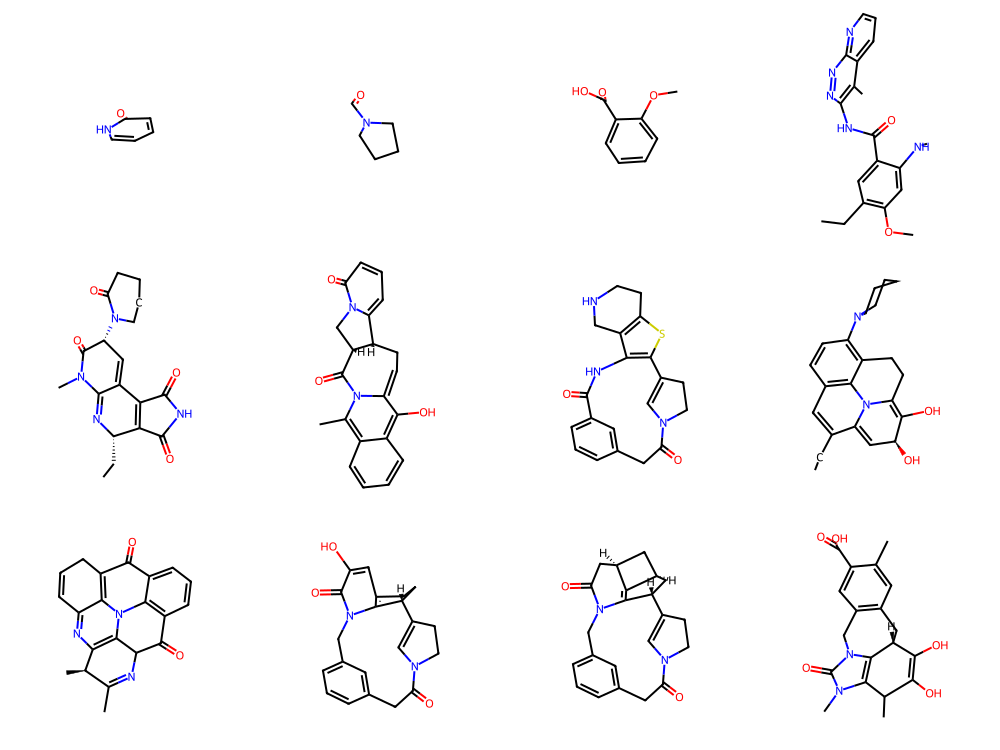

In [129]:
from rdkit.Chem import Draw    # RDKit module for drawing 2D molecular structures
from PIL import Image           # PIL = Python Imaging Library, for saving images
import glob                     # for finding multiple files matching a pattern

# Find all SDF files in Pocket2Mol output directory
# glob.glob = returns list of all files matching the pattern
sdf_files = glob.glob('outputs/pocket2mol/sample_4eiy_clean.pdb_2026_04_28__12_28_34/SDF_pt_files/sdf/*.sdf')
sdf_files = sorted(sdf_files)[:12]   # take first 12 — enough for visualization

print(f"Found {len(sdf_files)} SDF files")

# Load each molecule from its SDF file
viz_mols = []
for f in sdf_files:
    suppl = Chem.SDMolSupplier(f)    # SDMolSupplier reads SDF files
    for mol in suppl:
        if mol is not None:           # skip invalid molecules
            viz_mols.append(mol)

print(f"Loaded {len(viz_mols)} molecules")

# Draw molecules in a 4x3 grid
# MolsToGridImage = arranges multiple molecules in a grid layout
img = Draw.MolsToGridImage(
    viz_mols[:12],           # first 12 molecules
    molsPerRow=4,            # 4 molecules per row → 3 rows total
    subImgSize=(250, 250),   # size of each molecule image in pixels
    returnPNG=False          # return PIL Image object (not raw PNG bytes)
)

# Save to figures folder
img.save('figures/pocket2mol_example_molecules.png')
print("Saved to figures/pocket2mol_example_molecules.png")
img   # display in notebook

## Overall Drug-likeness Summary

This section provides a combined assessment of all molecular properties 
against established drug-like ranges. A molecule is considered drug-like 
if its properties fall within the ideal ranges defined by Lipinski's Rule 
of Five and complementary metrics (QED, SA Score).

**Green bar** = property mean is within ideal range ✓  
**Red dashed line** = upper limit | **Blue dashed line** = lower limit

Property         Mean        Ideal Range     Status
MW (Da)        294.52          150 – 500     ✓ PASS
LogP             2.05         -0.4 – 5.6     ✓ PASS
HBA              3.45             0 – 10     ✓ PASS
HBD              1.42              0 – 5     ✓ PASS
TPSA (Å²)       66.68            0 – 140     ✓ PASS
QED              0.72          0.5 – 1.0     ✓ PASS
SA Score         3.52              1 – 4     ✓ PASS

Overall: 7/7 properties within ideal range
Drug-likeness: EXCELLENT


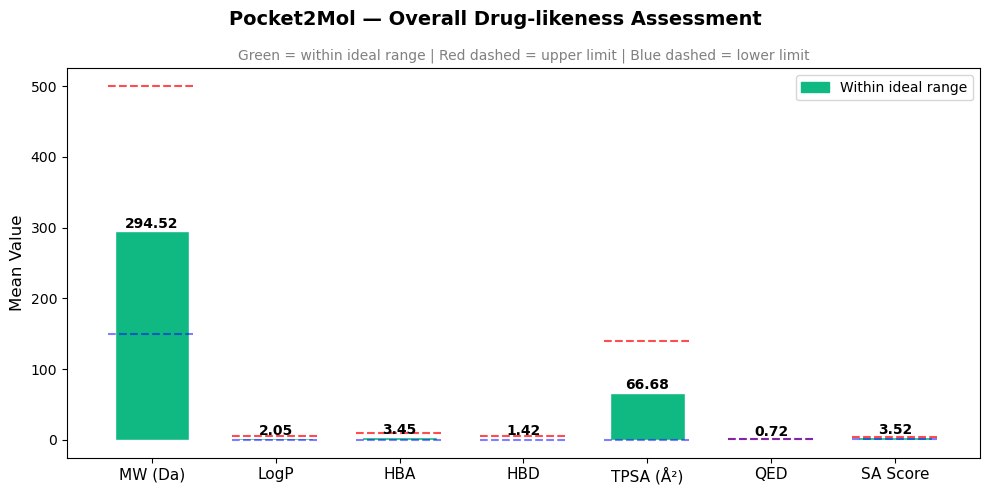

Saved to figures/pocket2mol_druglikeness_summary.png


In [131]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Define all properties with their mean values and ideal drug-like ranges
# Ideal ranges from Lipinski Rule of Five + additional drug-likeness criteria
properties = ['MW (Da)', 'LogP', 'HBA', 'HBD', 'TPSA (Å²)', 'QED', 'SA Score']

# Calculate mean for each property from our generated molecules
means = [
    df['MW'].mean(),         # mean molecular weight
    df['LogP'].mean(),       # mean lipophilicity
    df['HBA'].mean(),        # mean H-bond acceptors
    df['HBD'].mean(),        # mean H-bond donors
    df['TPSA'].mean(),       # mean polar surface area
    df['QED'].mean(),        # mean drug-likeness score
    df['SA_score'].mean()    # mean synthetic accessibility
]

# Ideal ranges for each property
# Source: Lipinski (1997), Bickerton et al. (2012), Ertl & Schuffenhauer (2009)
ideal_min = [150,  -0.4,  0,  0,   0,  0.5,  1]   # lower bounds
ideal_max = [500,   5.6, 10,  5, 140,  1.0,  4]   # upper bounds

# Check if each mean falls within its ideal range
# True = property is drug-like, False = outside ideal range
in_range = [ideal_min[i] <= means[i] <= ideal_max[i] for i in range(len(means))]

# Print summary table to console
print("=" * 65)
print(f"{'Property':<12} {'Mean':>8} {'Ideal Range':>18} {'Status':>10}")
print("=" * 65)
for i, (prop, mean, lo, hi, ok) in enumerate(zip(properties, means, ideal_min, ideal_max, in_range)):
    status = "✓ PASS" if ok else "✗ FAIL"   # green check or red cross
    print(f"{prop:<12} {mean:>8.2f} {f'{lo} – {hi}':>18} {status:>10}")
print("=" * 65)
print(f"\nOverall: {sum(in_range)}/{len(in_range)} properties within ideal range")
print(f"Drug-likeness: {'EXCELLENT' if sum(in_range) == len(in_range) else 'GOOD'}")

# Bar chart showing mean value per property
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Pocket2Mol — Overall Drug-likeness Assessment', fontsize=14, fontweight='bold')

# Green bars = within ideal range, Red bars = outside ideal range
colors = ['#10B981' if ok else '#EF4444' for ok in in_range]
x = np.arange(len(properties))   # x positions for bars
bars = ax.bar(x, means, color=colors, edgecolor='white', width=0.6)

# Draw ideal range lines for each property
# Red dashed = upper limit, Blue dashed = lower limit
for i, (lo, hi) in enumerate(zip(ideal_min, ideal_max)):
    ax.plot([i-0.35, i+0.35], [hi, hi], 'r--', linewidth=1.5, alpha=0.7)  # upper limit
    ax.plot([i-0.35, i+0.35], [lo, lo], 'b--', linewidth=1.5, alpha=0.5)  # lower limit

ax.set_xticks(x)
ax.set_xticklabels(properties, fontsize=11)
ax.set_ylabel('Mean Value', fontsize=12)
ax.set_title('Green = within ideal range | Red dashed = upper limit | Blue dashed = lower limit',
             fontsize=10, color='gray')

# Add mean value label on top of each bar
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{mean:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Legend
green_patch = mpatches.Patch(color='#10B981', label='Within ideal range')
ax.legend(handles=[green_patch], fontsize=10)

plt.tight_layout()   # automatically adjust spacing
plt.savefig('figures/pocket2mol_druglikeness_summary.png', dpi=150)
plt.show()
print("Saved to figures/pocket2mol_druglikeness_summary.png")

### Top Drug-like Molecules

Molecules with the best overall drug-likeness profile:
- Lipinski = 0 violations
- QED > 0.7 (high drug-likeness)
- SA Score ≤ 4 (synthesizable)
- Tanimoto < 0.3 (novel)

In [132]:
# Filter top drug-like molecules
# All 4 criteria must be met simultaneously
top_mols = df[
    (df['Lipinski'] == 0) &      # no Lipinski violations
    (df['QED'] > 0.7) &          # high drug-likeness score
    (df['SA_score'] <= 4) &      # easy to synthesize
    (df['max_tanimoto'] < 0.3)   # novel vs known A2A actives
].copy()

# Sort by QED descending — best drug-like first
top_mols = top_mols.sort_values('QED', ascending=False)

print(f"Top drug-like molecules: {len(top_mols)}")
print(f"(Lipinski=0, QED>0.7, SA≤4, Tanimoto<0.3)\n")
top_mols[['smiles','MW','LogP','QED','SA_score','max_tanimoto','nearest_active']].head(10)

Top drug-like molecules: 46
(Lipinski=0, QED>0.7, SA≤4, Tanimoto<0.3)



,smiles,MW,LogP,QED,SA_score,max_tanimoto,nearest_active
50,COc1ccc(CN2CC(C)(c3ccc(O)cc3)CC2=O)c(C)c1,325.41,3.40,0.937,2.89,0.198,A2A_Active_10
31,CC(Cc1ccccc1)C1=NN(C)C(c2ccccc2)N1,279.39,3.41,0.928,3.26,0.200,A2A_Active_16
87,O=C(O)c1cnc2c(ccc(=O)n2C(=O)C2CCCC2)c1N1CCCC1,355.39,2.53,0.909,2.60,0.175,A2A_Active_10
90,CCc1cc2c(cc1C(=O)O)CN1C(=O)N(C)c3nc(C)ncc3C1=C2,350.38,2.93,0.900,3.19,0.175,A2A_Active_5
49,C=C(C)c1nc2c(s1)C(=O)NCc1c-2cccc1N1CCCCC1,339.46,4.08,0.897,2.94,0.161,A2A_Active_10
92,COc1cc(C)c(CN2CC(C)(c3ccc(O)cc3)CC2=O)cc1OC,355.43,3.41,0.893,2.95,0.189,A2A_Active_20
57,CC(C)c1nc2c(s1)C(=O)NCc1c-2cccc1N1CCCCC1,341.48,4.17,0.892,2.73,0.165,A2A_Active_10
38,CC(=O)NCC(=O)N1CC(c2ccccc2O)=C2CCCC21,300.36,1.68,0.892,3.17,0.153,A2A_Active_30
36,COc1cc(O)c2c(O)cc(C3CCN(C(C)=O)C3)nc2c1,302.33,1.99,0.886,3.03,0.173,A2A_Active_10
20,COc1ccccc1NC(=O)c1cccs1,233.29,3.01,0.885,1.56,0.207,A2A_Active_30


### 2D Structures of Top Drug-like Molecules

Visual representation of the 10 best candidates based on 
QED, SA Score, Lipinski compliance, and novelty.

Saved to figures/pocket2mol_top10_druglike.png


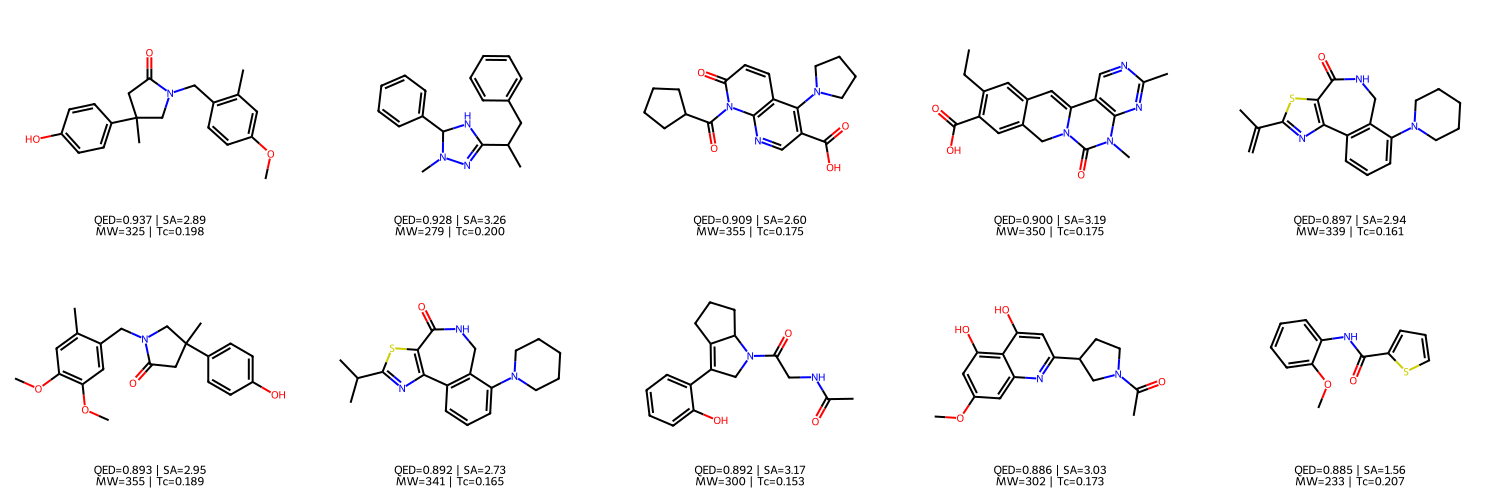

In [133]:
from rdkit.Chem import Draw
from PIL import Image

# Convert top molecules SMILES to RDKit mol objects
top_viz = []
legends = []

for _, row in top_mols.head(10).iterrows():
    mol = Chem.MolFromSmiles(row['smiles'])
    if mol:
        top_viz.append(mol)
        # Label each molecule with key stats
        legends.append(
            f"QED={row['QED']:.3f} | SA={row['SA_score']:.2f}\n"
            f"MW={row['MW']:.0f} | Tc={row['max_tanimoto']:.3f}"
        )

# Draw in a 5x2 grid
img = Draw.MolsToGridImage(
    top_viz,
    molsPerRow=5,            # 5 molecules per row = 2 rows total
    subImgSize=(300, 250),   # size of each molecule image
    legends=legends,         # show stats under each molecule
    returnPNG=False
)

img.save('figures/pocket2mol_top10_druglike.png')
print("Saved to figures/pocket2mol_top10_druglike.png")
img